In [1]:
import sys
from pathlib import Path
import torch
import numpy as np

script_dir = Path.cwd()
sys.path.insert(0, str(script_dir.parent.parent))

from config import PROJECT_ROOT, EGEMAPS_DROPOUT
from model import AD_EGE_Model
from dataset import create_dataloaders, FeatureDataset
from train import validate
from train_ST_egemaps import train_st_egemaps
from visualization import plot_training_curves, plot_dataset_comparison

In [2]:
SOURCE_DATASET = "Pitt"
TARGET_DATASET = "Lu"

# Model Selection Weights and Thresholds
SOURCE_WEIGHT = 0.5  # Weight for source domain validation accuracy
TARGET_WEIGHT = 0.5  # Weight for target domain validation accuracy

# Self-Training Hyperparameters
ST_WARMUP_EPOCHS = 30           # Number of epochs to train on source domain before applying ST (iteration 0)
ST_MAX_EPOCHS = 60              # Number of epochs for each ST iteration (iteration 1+)
CONFIDENCE_THRESHOLD = 0.9
MAX_ITERATIONS = 5
MIN_PSEUDO_SAMPLES = 5
BATCH_SIZE = 12

# eGeMAPS Model Parameters
DIM_INPUT = 25
DIM_HIDDEN = 32
DROPOUT = 0.3

# Device setup
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"Device: {device}")

Device: mps


In [3]:
data_dir = PROJECT_ROOT / "data" / "processed"

SOURCE_TRAIN_CSV = data_dir / f"{SOURCE_DATASET}-egemaps-train.csv"
SOURCE_VAL_CSV = data_dir / f"{SOURCE_DATASET}-egemaps-val.csv"
TARGET_TRAIN_CSV = data_dir / f"{TARGET_DATASET}-egemaps-train.csv"
TARGET_VAL_CSV = data_dir / f"{TARGET_DATASET}-egemaps-val.csv"

MODEL_OUTPUT_DIR = PROJECT_ROOT / "models" / f"ST_{SOURCE_DATASET}_to_{TARGET_DATASET}_egemaps_t{int(CONFIDENCE_THRESHOLD*100)}"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Output: {MODEL_OUTPUT_DIR}")

Output: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/ST_Pitt_to_Lu_egemaps_t90


## 1 Load Data

In [4]:
source_train_dataset = FeatureDataset(SOURCE_TRAIN_CSV, xlsr=False)
target_train_dataset = FeatureDataset(TARGET_TRAIN_CSV, xlsr=False)

source_val_loader = create_dataloaders(SOURCE_VAL_CSV, xlsr=False, batch_size=BATCH_SIZE)
target_val_loader = create_dataloaders(TARGET_VAL_CSV, xlsr=False, batch_size=BATCH_SIZE)

Loading completed: 440 samples
Control: 193, Dementia: 247


Loading completed: 58 samples
Control: 28, Dementia: 30


Loading completed: 111 samples
Control: 49, Dementia: 62


Loading completed: 16 samples
Control: 8, Dementia: 8




## 2 Define Evaluation Functions

In [5]:
# Evaluation helper for all seeds
def evaluate_and_visualize_st(seed, all_metrics, all_histories, all_pseudo_stats,
                              source_val_loader, target_val_loader, output_dir, device):
    """Evaluate best ST iteration and visualize source vs target performance."""
    if not all_metrics:
        raise ValueError('all_metrics is empty; run training first.')

    # Pick best iteration by avg_val_acc
    best_iter_idx = max(
        range(len(all_metrics)),
        key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0
    )
    best_metric = all_metrics[best_iter_idx]

    print('='*60)
    print(f"Evaluating Best Model (Seed {seed})")
    print(f"Best Iteration: {best_iter_idx}")
    if best_metric:
        print(f"Best Avg Acc: {best_metric.get('avg_val_acc', 0)*100:.2f}%")
        print(f"  Source: {best_metric.get('source_val_acc', 0)*100:.2f}%")
        print(f"  Target: {best_metric.get('target_val_acc', 0)*100:.2f}%")
    print('='*60)

    model_path = output_dir / f"seed_{seed}" / f"st_iter_{best_iter_idx}.pth"
    print(f"Loading model from: {model_path}")

    best_model = AD_EGE_Model(dim_input=DIM_INPUT, dim_hidden=DIM_HIDDEN, dropout=DROPOUT).to(device)
    best_model.load_state_dict(torch.load(model_path, map_location=device))

    source_loss, source_acc, source_control_acc, source_dementia_acc, source_f1 = validate(
        best_model, source_val_loader, device
    )
    target_loss, target_acc, target_control_acc, target_dementia_acc, target_f1 = validate(
        best_model, target_val_loader, device
    )

    print(f"\n{'Dataset':<25} {'Accuracy':<12} {'F1 Score':<12} {'Dementia':<12} {'Control':<12} {'Loss':<10}")
    print('-'*85)
    print(f"{f'{SOURCE_DATASET} (source domain)':<25} {source_acc*100:>10.2f}%  {source_f1:>10.4f}  {source_dementia_acc*100:>10.2f}%  {source_control_acc*100:>10.2f}%  {source_loss:>8.4f}")
    print(f"{f'{TARGET_DATASET} (target domain)':<25} {target_acc*100:>10.2f}%  {target_f1:>10.4f}  {target_dementia_acc*100:>10.2f}%  {target_control_acc*100:>10.2f}%  {target_loss:>8.4f}")
    print('-'*85)

    loaded_avg_acc = SOURCE_WEIGHT * source_acc + TARGET_WEIGHT * target_acc
    expected_avg_acc = best_metric.get('avg_val_acc', 0)
    if abs(loaded_avg_acc - expected_avg_acc) > 0.01:
        print("\n⚠️  WARNING: Loaded model accuracy mismatch!")
        print(f"   Expected avg acc: {expected_avg_acc*100:.2f}%")
        print(f"   Actual avg acc:   {loaded_avg_acc*100:.2f}%")
    else:
        print(f"\n✓ Model verification passed (avg acc: {loaded_avg_acc*100:.2f}%)")

    dataset_names = [f'{SOURCE_DATASET} (source)', f'{TARGET_DATASET} (target)']
    accuracies = [source_acc * 100, target_acc * 100]
    plot_dataset_comparison(
        dataset_names=dataset_names,
        accuracies=accuracies,
        title=f'eGeMAPS-ST Performance (Seed {seed}, Iter {best_iter_idx})',
        custom_colors={
            f'{SOURCE_DATASET} (source)': '#3498db',
            f'{TARGET_DATASET} (target)': '#e74c3c'
        }
    )

    source_metrics = {
        'acc': source_acc, 'f1': source_f1,
        'dementia_acc': source_dementia_acc,
        'control_acc': source_control_acc,
        'loss': source_loss
    }
    target_metrics = {
        'acc': target_acc, 'f1': target_f1,
        'dementia_acc': target_dementia_acc,
        'control_acc': target_control_acc,
        'loss': target_loss
    }
    return source_metrics, target_metrics

## 3 Training with Multiple Seeds

In [6]:
all_results = {
    'seeds': [],
    'metrics': [],
    'histories': [],
    'pseudo_stats': [],
    'source_metrics': [],
    'target_metrics': []
}

### Seed 21


Self-Training (eGeMAPS): Seed 21
Model Selection: Avg Acc (Source 0.5, Target 0.5)
Confidence Threshold: 0.9
Max Iterations: 5

Iteration 0: Initial training on source domain only

ST Iteration 0 - Training (eGeMAPS)
Model Selection: Avg Acc (Source 0.5, Target 0.5)


Epoch   1 | Train: 0.539 | Source Val: 0.450 | Target Val: 0.500 | Avg: 0.475


Epoch   2 | Train: 0.566 | Source Val: 0.559 | Target Val: 0.500 | Avg: 0.529


Epoch   3 | Train: 0.561 | Source Val: 0.550 | Target Val: 0.500 | Avg: 0.525


Epoch   4 | Train: 0.580 | Source Val: 0.559 | Target Val: 0.500 | Avg: 0.529


...

Epoch  15 | Train: 0.623 | Source Val: 0.541 | Target Val: 0.500 | Avg: 0.520


Epoch  16 | Train: 0.627 | Source Val: 0.423 | Target Val: 0.250 | Avg: 0.337


Epoch  17 | Train: 0.639 | Source Val: 0.477 | Target Val: 0.312 | Avg: 0.395
Early stopping at epoch 17 (best epoch: 7)

Iteration 0 Best Results (Epoch 7):
  Avg Acc: 56.50%
  Source Acc: 56.76% | F1: 0.7209
  Target Acc: 56.25% | F1: 0.6957

Iteration 1: Generating pseudo-labels...



Pseudo-label Generation (threshold=0.90):
  Total target samples: 58, Selected: 0 (0.0%)
  Control: 0, Dementia: 0

⚠️  Stopping: Only 0 pseudo-labels (< 5)

Self-Training Summary (eGeMAPS, Seed 21)
Best iteration: 0
Best avg accuracy: 56.50%

Per-Iteration Results:
Iter   Avg Acc      Source Acc   Target Acc   Source F1    Target F1    Pseudo    
--------------------------------------------------------------------------------
0           56.50%      56.76%      56.25%     0.7209     0.6957        0
Evaluating Best Model (Seed 21)
Best Iteration: 0
Best Avg Acc: 56.50%
  Source: 56.76%
  Target: 56.25%
Loading model from: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/ST_Pitt_to_Lu_egemaps_t90/seed_21/st_iter_0.pth



Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
Pitt (source domain)           56.76%      0.7209      100.00%        2.04%    0.7152
Lu (target domain)             56.25%      0.6957      100.00%       12.50%    0.7878
-------------------------------------------------------------------------------------

✓ Model verification passed (avg acc: 56.50%)


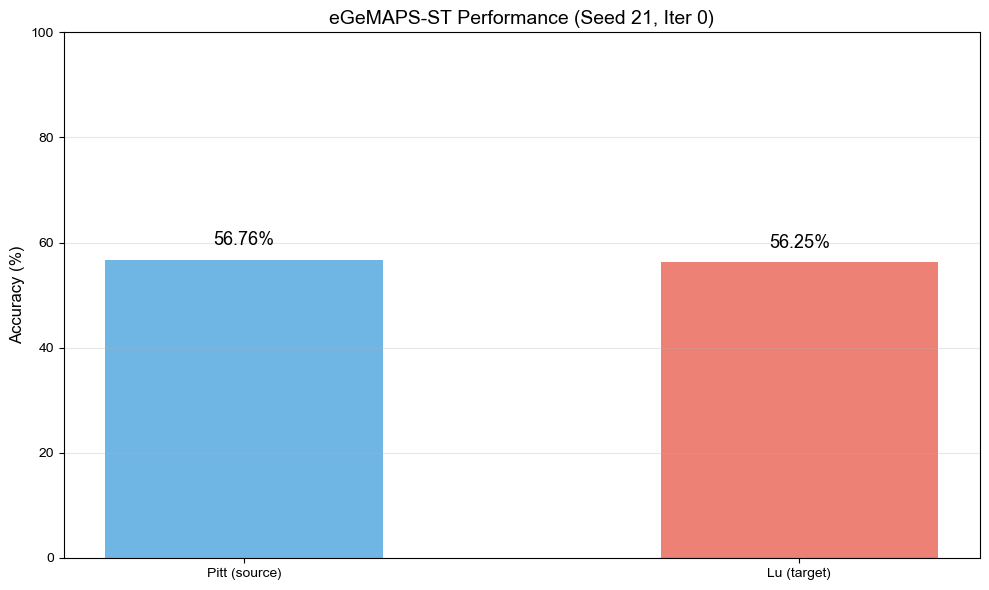

In [7]:
seed = 21

seed, all_metrics, all_histories, all_pseudo_stats = train_st_egemaps(
    seed=seed,
    source_train_dataset=source_train_dataset,
    target_train_dataset=target_train_dataset,
    source_val_loader=source_val_loader,
    target_val_loader=target_val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device,
    max_iterations=MAX_ITERATIONS,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    min_pseudo_samples=MIN_PSEUDO_SAMPLES,
    warmup_epochs=ST_WARMUP_EPOCHS,
    max_epochs=ST_MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    dim_input=DIM_INPUT,
    dim_hidden=DIM_HIDDEN,
    dropout=DROPOUT,
    source_weight=SOURCE_WEIGHT,
    target_weight=TARGET_WEIGHT
)

# Evaluate and visualize
source_metrics, target_metrics = evaluate_and_visualize_st(
    seed, all_metrics, all_histories, all_pseudo_stats,
    source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device
)

# Store results
all_results['seeds'].append(seed)
all_results['metrics'].append(all_metrics)
all_results['histories'].append(all_histories)
all_results['pseudo_stats'].append(all_pseudo_stats)
all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

### Seed 42


Self-Training (eGeMAPS): Seed 42
Model Selection: Avg Acc (Source 0.5, Target 0.5)
Confidence Threshold: 0.9
Max Iterations: 5

Iteration 0: Initial training on source domain only

ST Iteration 0 - Training (eGeMAPS)
Model Selection: Avg Acc (Source 0.5, Target 0.5)


Epoch   1 | Train: 0.534 | Source Val: 0.559 | Target Val: 0.438 | Avg: 0.498


Epoch   2 | Train: 0.518 | Source Val: 0.559 | Target Val: 0.500 | Avg: 0.529


Epoch   3 | Train: 0.555 | Source Val: 0.514 | Target Val: 0.312 | Avg: 0.413


Epoch   4 | Train: 0.573 | Source Val: 0.586 | Target Val: 0.312 | Avg: 0.449


...

Epoch  28 | Train: 0.648 | Source Val: 0.495 | Target Val: 0.250 | Avg: 0.373


Epoch  29 | Train: 0.641 | Source Val: 0.495 | Target Val: 0.500 | Avg: 0.498


Epoch  30 | Train: 0.614 | Source Val: 0.514 | Target Val: 0.500 | Avg: 0.507

Iteration 0 Best Results (Epoch 27):
  Avg Acc: 60.98%
  Source Acc: 59.46% | F1: 0.7134
  Target Acc: 62.50% | F1: 0.7273

Iteration 1: Generating pseudo-labels...



Pseudo-label Generation (threshold=0.90):
  Total target samples: 58, Selected: 0 (0.0%)
  Control: 0, Dementia: 0

⚠️  Stopping: Only 0 pseudo-labels (< 5)

Self-Training Summary (eGeMAPS, Seed 42)
Best iteration: 0
Best avg accuracy: 60.98%

Per-Iteration Results:
Iter   Avg Acc      Source Acc   Target Acc   Source F1    Target F1    Pseudo    
--------------------------------------------------------------------------------
0           60.98%      59.46%      62.50%     0.7134     0.7273        0
Evaluating Best Model (Seed 42)
Best Iteration: 0
Best Avg Acc: 60.98%
  Source: 59.46%
  Target: 62.50%
Loading model from: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/ST_Pitt_to_Lu_egemaps_t90/seed_42/st_iter_0.pth



Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
Pitt (source domain)           59.46%      0.7134       90.32%       20.41%    0.6903
Lu (target domain)             62.50%      0.7273      100.00%       25.00%    0.6936
-------------------------------------------------------------------------------------

✓ Model verification passed (avg acc: 60.98%)


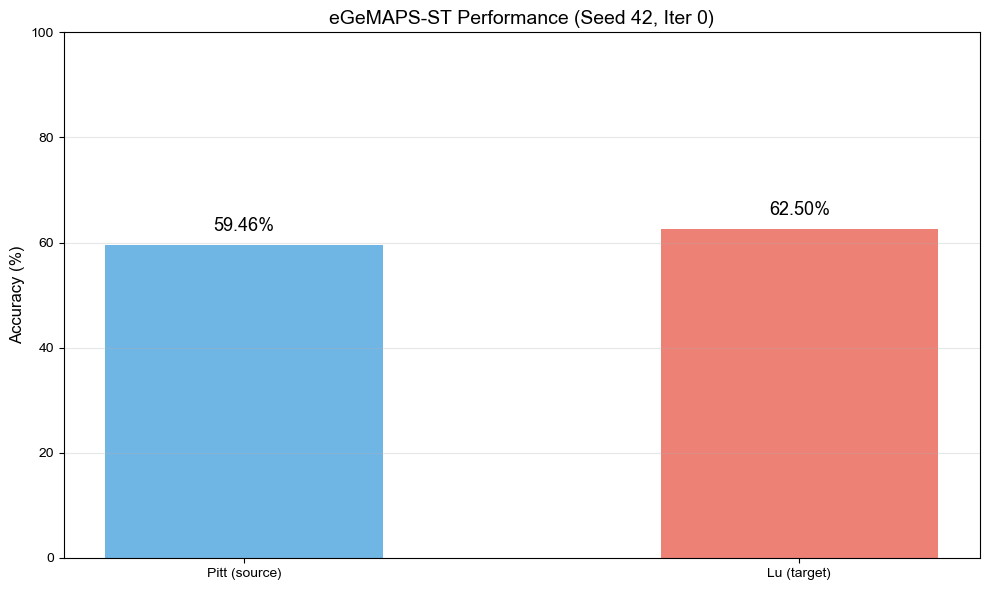

In [8]:
seed = 42

seed, all_metrics, all_histories, all_pseudo_stats = train_st_egemaps(
    seed=seed,
    source_train_dataset=source_train_dataset,
    target_train_dataset=target_train_dataset,
    source_val_loader=source_val_loader,
    target_val_loader=target_val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device,
    max_iterations=MAX_ITERATIONS,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    min_pseudo_samples=MIN_PSEUDO_SAMPLES,
    warmup_epochs=ST_WARMUP_EPOCHS,
    max_epochs=ST_MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    dim_input=DIM_INPUT,
    dim_hidden=DIM_HIDDEN,
    dropout=DROPOUT,
    source_weight=SOURCE_WEIGHT,
    target_weight=TARGET_WEIGHT
)

# Evaluate and visualize
source_metrics, target_metrics = evaluate_and_visualize_st(
    seed, all_metrics, all_histories, all_pseudo_stats,
    source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device
)

# Store results
all_results['seeds'].append(seed)
all_results['metrics'].append(all_metrics)
all_results['histories'].append(all_histories)
all_results['pseudo_stats'].append(all_pseudo_stats)
all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

### Seed 84


Self-Training (eGeMAPS): Seed 84
Model Selection: Avg Acc (Source 0.5, Target 0.5)
Confidence Threshold: 0.9
Max Iterations: 5

Iteration 0: Initial training on source domain only

ST Iteration 0 - Training (eGeMAPS)
Model Selection: Avg Acc (Source 0.5, Target 0.5)


Epoch   1 | Train: 0.509 | Source Val: 0.532 | Target Val: 0.500 | Avg: 0.516


Epoch   2 | Train: 0.559 | Source Val: 0.550 | Target Val: 0.500 | Avg: 0.525


Epoch   3 | Train: 0.536 | Source Val: 0.541 | Target Val: 0.500 | Avg: 0.520


Epoch   4 | Train: 0.552 | Source Val: 0.568 | Target Val: 0.562 | Avg: 0.565


...

Epoch  12 | Train: 0.582 | Source Val: 0.577 | Target Val: 0.500 | Avg: 0.538


Epoch  13 | Train: 0.602 | Source Val: 0.559 | Target Val: 0.500 | Avg: 0.529


Epoch  14 | Train: 0.593 | Source Val: 0.486 | Target Val: 0.375 | Avg: 0.431
Early stopping at epoch 14 (best epoch: 4)

Iteration 0 Best Results (Epoch 4):
  Avg Acc: 56.50%
  Source Acc: 56.76% | F1: 0.7108
  Target Acc: 56.25% | F1: 0.6957

Iteration 1: Generating pseudo-labels...



Pseudo-label Generation (threshold=0.90):
  Total target samples: 58, Selected: 0 (0.0%)
  Control: 0, Dementia: 0

⚠️  Stopping: Only 0 pseudo-labels (< 5)

Self-Training Summary (eGeMAPS, Seed 84)
Best iteration: 0
Best avg accuracy: 56.50%

Per-Iteration Results:
Iter   Avg Acc      Source Acc   Target Acc   Source F1    Target F1    Pseudo    
--------------------------------------------------------------------------------
0           56.50%      56.76%      56.25%     0.7108     0.6957        0
Evaluating Best Model (Seed 84)
Best Iteration: 0
Best Avg Acc: 56.50%
  Source: 56.76%
  Target: 56.25%
Loading model from: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/ST_Pitt_to_Lu_egemaps_t90/seed_84/st_iter_0.pth



Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
Pitt (source domain)           56.76%      0.7108       95.16%        8.16%    0.6736
Lu (target domain)             56.25%      0.6957      100.00%       12.50%    0.7085
-------------------------------------------------------------------------------------

✓ Model verification passed (avg acc: 56.50%)


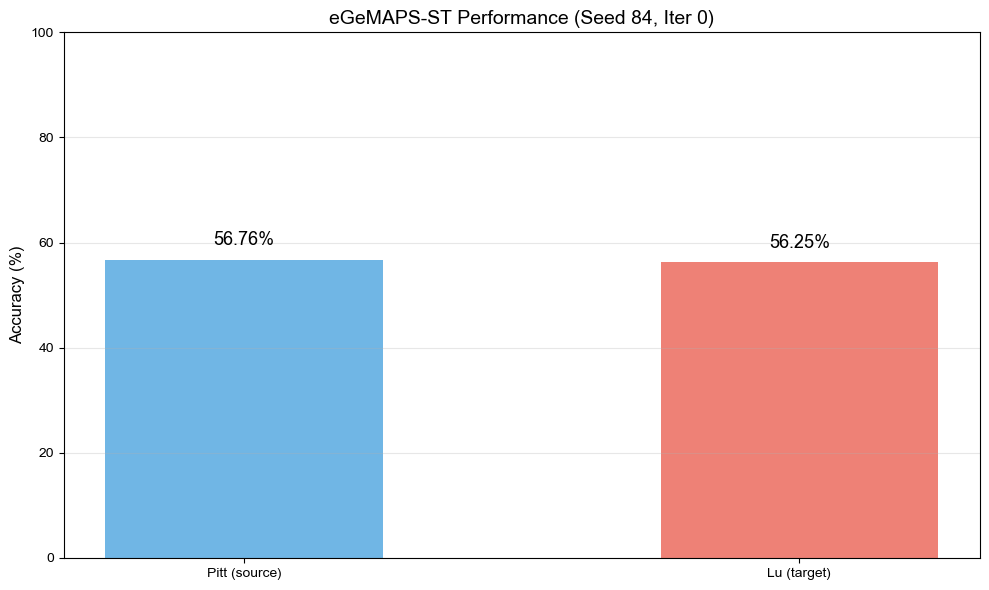

In [9]:
seed = 84

seed, all_metrics, all_histories, all_pseudo_stats = train_st_egemaps(
    seed=seed,
    source_train_dataset=source_train_dataset,
    target_train_dataset=target_train_dataset,
    source_val_loader=source_val_loader,
    target_val_loader=target_val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device,
    max_iterations=MAX_ITERATIONS,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    min_pseudo_samples=MIN_PSEUDO_SAMPLES,
    warmup_epochs=ST_WARMUP_EPOCHS,
    max_epochs=ST_MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    dim_input=DIM_INPUT,
    dim_hidden=DIM_HIDDEN,
    dropout=DROPOUT,
    source_weight=SOURCE_WEIGHT,
    target_weight=TARGET_WEIGHT
)

# Evaluate and visualize
source_metrics, target_metrics = evaluate_and_visualize_st(
    seed, all_metrics, all_histories, all_pseudo_stats,
    source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device
)

# Store results
all_results['seeds'].append(seed)
all_results['metrics'].append(all_metrics)
all_results['histories'].append(all_histories)
all_results['pseudo_stats'].append(all_pseudo_stats)
all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

### Seed 168


Self-Training (eGeMAPS): Seed 168
Model Selection: Avg Acc (Source 0.5, Target 0.5)
Confidence Threshold: 0.9
Max Iterations: 5

Iteration 0: Initial training on source domain only

ST Iteration 0 - Training (eGeMAPS)
Model Selection: Avg Acc (Source 0.5, Target 0.5)


Epoch   1 | Train: 0.493 | Source Val: 0.559 | Target Val: 0.500 | Avg: 0.529


Epoch   2 | Train: 0.564 | Source Val: 0.586 | Target Val: 0.500 | Avg: 0.543


Epoch   3 | Train: 0.559 | Source Val: 0.577 | Target Val: 0.562 | Avg: 0.570


Epoch   4 | Train: 0.570 | Source Val: 0.568 | Target Val: 0.562 | Avg: 0.565


...

Epoch  11 | Train: 0.598 | Source Val: 0.468 | Target Val: 0.375 | Avg: 0.422


Epoch  12 | Train: 0.595 | Source Val: 0.532 | Target Val: 0.500 | Avg: 0.516


Epoch  13 | Train: 0.600 | Source Val: 0.523 | Target Val: 0.562 | Avg: 0.543
Early stopping at epoch 13 (best epoch: 3)

Iteration 0 Best Results (Epoch 3):
  Avg Acc: 56.95%
  Source Acc: 57.66% | F1: 0.7219
  Target Acc: 56.25% | F1: 0.6957

Iteration 1: Generating pseudo-labels...



Pseudo-label Generation (threshold=0.90):
  Total target samples: 58, Selected: 0 (0.0%)
  Control: 0, Dementia: 0

⚠️  Stopping: Only 0 pseudo-labels (< 5)

Self-Training Summary (eGeMAPS, Seed 168)
Best iteration: 0
Best avg accuracy: 56.95%

Per-Iteration Results:
Iter   Avg Acc      Source Acc   Target Acc   Source F1    Target F1    Pseudo    
--------------------------------------------------------------------------------
0           56.95%      57.66%      56.25%     0.7219     0.6957        0
Evaluating Best Model (Seed 168)
Best Iteration: 0
Best Avg Acc: 56.95%
  Source: 57.66%
  Target: 56.25%
Loading model from: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/ST_Pitt_to_Lu_egemaps_t90/seed_168/st_iter_0.pth



Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
Pitt (source domain)           57.66%      0.7219       98.39%        6.12%    0.6822
Lu (target domain)             56.25%      0.6957      100.00%       12.50%    0.6995
-------------------------------------------------------------------------------------

✓ Model verification passed (avg acc: 56.95%)


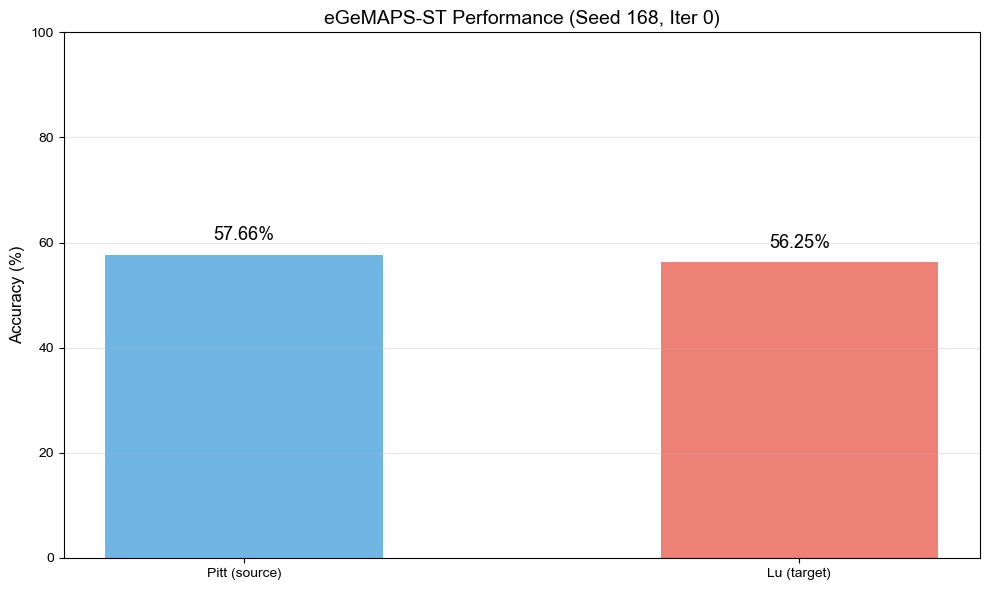

In [10]:
seed = 168

seed, all_metrics, all_histories, all_pseudo_stats = train_st_egemaps(
    seed=seed,
    source_train_dataset=source_train_dataset,
    target_train_dataset=target_train_dataset,
    source_val_loader=source_val_loader,
    target_val_loader=target_val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device,
    max_iterations=MAX_ITERATIONS,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    min_pseudo_samples=MIN_PSEUDO_SAMPLES,
    warmup_epochs=ST_WARMUP_EPOCHS,
    max_epochs=ST_MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    dim_input=DIM_INPUT,
    dim_hidden=DIM_HIDDEN,
    dropout=DROPOUT,
    source_weight=SOURCE_WEIGHT,
    target_weight=TARGET_WEIGHT
)

# Evaluate and visualize
source_metrics, target_metrics = evaluate_and_visualize_st(
    seed, all_metrics, all_histories, all_pseudo_stats,
    source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device
)

# Store results
all_results['seeds'].append(seed)
all_results['metrics'].append(all_metrics)
all_results['histories'].append(all_histories)
all_results['pseudo_stats'].append(all_pseudo_stats)
all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

### Seed 336


Self-Training (eGeMAPS): Seed 336
Model Selection: Avg Acc (Source 0.5, Target 0.5)
Confidence Threshold: 0.9
Max Iterations: 5

Iteration 0: Initial training on source domain only

ST Iteration 0 - Training (eGeMAPS)
Model Selection: Avg Acc (Source 0.5, Target 0.5)


Epoch   1 | Train: 0.564 | Source Val: 0.559 | Target Val: 0.375 | Avg: 0.467


Epoch   2 | Train: 0.543 | Source Val: 0.441 | Target Val: 0.562 | Avg: 0.502


Epoch   3 | Train: 0.561 | Source Val: 0.559 | Target Val: 0.500 | Avg: 0.529


Epoch   4 | Train: 0.541 | Source Val: 0.577 | Target Val: 0.562 | Avg: 0.570


...

Epoch  12 | Train: 0.582 | Source Val: 0.559 | Target Val: 0.500 | Avg: 0.529


Epoch  13 | Train: 0.614 | Source Val: 0.622 | Target Val: 0.500 | Avg: 0.561


Epoch  14 | Train: 0.614 | Source Val: 0.550 | Target Val: 0.375 | Avg: 0.462
Early stopping at epoch 14 (best epoch: 4)

Iteration 0 Best Results (Epoch 4):
  Avg Acc: 56.95%
  Source Acc: 57.66% | F1: 0.7186
  Target Acc: 56.25% | F1: 0.6957

Iteration 1: Generating pseudo-labels...



Pseudo-label Generation (threshold=0.90):
  Total target samples: 58, Selected: 0 (0.0%)
  Control: 0, Dementia: 0

⚠️  Stopping: Only 0 pseudo-labels (< 5)

Self-Training Summary (eGeMAPS, Seed 336)
Best iteration: 0
Best avg accuracy: 56.95%

Per-Iteration Results:
Iter   Avg Acc      Source Acc   Target Acc   Source F1    Target F1    Pseudo    
--------------------------------------------------------------------------------
0           56.95%      57.66%      56.25%     0.7186     0.6957        0
Evaluating Best Model (Seed 336)
Best Iteration: 0
Best Avg Acc: 56.95%
  Source: 57.66%
  Target: 56.25%
Loading model from: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/ST_Pitt_to_Lu_egemaps_t90/seed_336/st_iter_0.pth



Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
Pitt (source domain)           57.66%      0.7186       96.77%        8.16%    0.6874
Lu (target domain)             56.25%      0.6957      100.00%       12.50%    0.7229
-------------------------------------------------------------------------------------

✓ Model verification passed (avg acc: 56.95%)


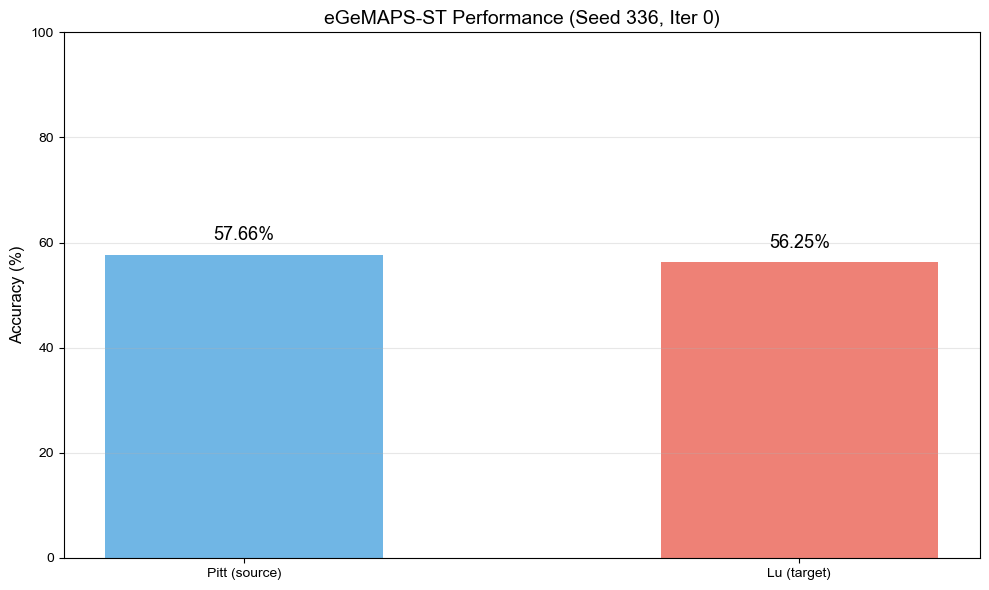

In [11]:
seed = 336

seed, all_metrics, all_histories, all_pseudo_stats = train_st_egemaps(
    seed=seed,
    source_train_dataset=source_train_dataset,
    target_train_dataset=target_train_dataset,
    source_val_loader=source_val_loader,
    target_val_loader=target_val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device,
    max_iterations=MAX_ITERATIONS,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    min_pseudo_samples=MIN_PSEUDO_SAMPLES,
    warmup_epochs=ST_WARMUP_EPOCHS,
    max_epochs=ST_MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    dim_input=DIM_INPUT,
    dim_hidden=DIM_HIDDEN,
    dropout=DROPOUT,
    source_weight=SOURCE_WEIGHT,
    target_weight=TARGET_WEIGHT
)

# Evaluate and visualize
source_metrics, target_metrics = evaluate_and_visualize_st(
    seed, all_metrics, all_histories, all_pseudo_stats,
    source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device
)

# Store results
all_results['seeds'].append(seed)
all_results['metrics'].append(all_metrics)
all_results['histories'].append(all_histories)
all_results['pseudo_stats'].append(all_pseudo_stats)
all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

## 4 Summary Statistics

In [13]:
import numpy as np

print("="*80)
print(f"eGeMAPS-ST Domain Adaptation Results: {SOURCE_DATASET} → {TARGET_DATASET}")
print("="*80)

# Extract metrics
source_accs = [m['acc'] for m in all_results['source_metrics']]
target_accs = [m['acc'] for m in all_results['target_metrics']]
source_f1s = [m['f1'] for m in all_results['source_metrics']]
target_f1s = [m['f1'] for m in all_results['target_metrics']]

# Compute statistics
print(f"\n{'Domain':<25} {'Mean Acc':<12} {'Std Acc':<12} {'Mean F1':<12} {'Std F1':<12}")
print("-"*80)
print(f"{f'{SOURCE_DATASET} (source)':<25} {np.mean(source_accs)*100:>10.2f}% {np.std(source_accs)*100:>10.2f}% {np.mean(source_f1s):>10.4f} {np.std(source_f1s):>10.4f}")
print(f"{f'{TARGET_DATASET} (target)':<25} {np.mean(target_accs)*100:>10.2f}% {np.std(target_accs)*100:>10.2f}% {np.mean(target_f1s):>10.4f} {np.std(target_f1s):>10.4f}")
print("-"*80)

# Per-seed results
print(f"\n{'Seed':<8} {'Source Acc':<15} {'Target Acc':<15} {'Source F1':<15} {'Target F1':<15}")
print("-"*80)
for i, seed in enumerate(all_results['seeds']):
    print(f"{seed:<8} {source_accs[i]*100:>13.2f}% {target_accs[i]*100:>13.2f}% {source_f1s[i]:>13.4f} {target_f1s[i]:>13.4f}")

eGeMAPS-ST Domain Adaptation Results: Pitt → Lu

Domain                    Mean Acc     Std Acc      Mean F1      Std F1      
--------------------------------------------------------------------------------
Pitt (source)                  57.66%       0.99%     0.7171     0.0043
Lu (target)                    57.50%       2.50%     0.7020     0.0126
--------------------------------------------------------------------------------

Seed     Source Acc      Target Acc      Source F1       Target F1      
--------------------------------------------------------------------------------
21               56.76%         56.25%        0.7209        0.6957
42               59.46%         62.50%        0.7134        0.7273
84               56.76%         56.25%        0.7108        0.6957
168              57.66%         56.25%        0.7219        0.6957
336              57.66%         56.25%        0.7186        0.6957
